In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.constants import G

$$
F = G\frac{m_1 \cdot m_2}{r^2}
$$

In [2]:
class Body:
    
    def __init__(self, m, x0, v0):
        self.m = m
        self.x = np.array(x0)
        self.v = np.array(v0)
        self.trajectoire = [self.x.copy()]

    def force(self, body):
        dx = self.x - body.x
        return - G * self.m * body.m * dx / np.linalg.norm(dx) ** 3

    def apply_force(self, F, dt):
        self.v += F / self.m * dt
        self.x += self.v * dt
        self.trajectoire.append(self.x.copy())

In [3]:
class Solver:

    def __init__(self, bodies):
        self.bodies = bodies

    def update(self, dt):
        for b0 in self.bodies:
            F = np.zeros(self.bodies[0].x.shape)
            for b1 in self.bodies:
                if b0 is not b1:
                    F += b0.force(b1)
            b0.apply_force(F, dt)

    def solve(self, t):
        dts = np.diff(t)
        for dt in dts:
            self.update(dt)
        for body in self.bodies:
            body.trajectoire = np.array(body.trajectoire)

In [11]:
bodies = [
    Body(1e3, [0., 0.], [0., 0.]),
    Body(1e-3, [0., 10.], [1e-4, 0.]),
    Body(1e-2, [-10., -10.], [0., 1e-4]),
]
solver = Solver(bodies)

In [12]:
t = np.linspace(0, 3e6, 100000)
solver.solve(t)

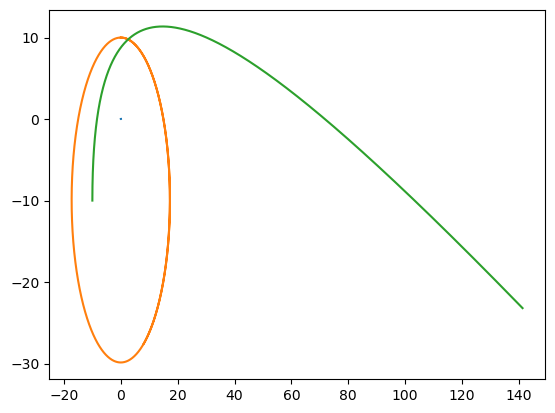

In [13]:
fig, axe = plt.subplots()
for body in bodies:
    axe.plot(*body.trajectoire.T)